In [1]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from pandas import DataFrame, read_excel
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier

In [27]:
filename = "../Database/DataCollection.xlsx"
model_dataset: DataFrame = read_excel(filename, sheet_name="791 Records")
PubChem_dataset: DataFrame = read_excel(filename, sheet_name="PubChem Database 9496 Solvents")

In [3]:
model_dataset_time = model_dataset["Time (min)"].dropna().to_numpy(dtype=int)
model_dataset_temperature = model_dataset["Temperature (K)"].dropna().to_numpy()

In [4]:
def get_unique_values(data, min_val, max_val):
    return np.sort(np.unique(data[(data >= min_val) & (data <= max_val)]))

In [5]:
unique_time_values = get_unique_values(model_dataset_time, 1, 500)

`GB Evaluation Models`

In [ ]:
dissolve_encoding: dict[str, int] = {"NO": 0,"YES": 1}
sample_type_enconding: dict[str, int] = {"pellet": 0, "waste": 1, "fiber": 2, "film": 3, "powder": 4}

encoding: dict[str, dict[str, int]] = {"Dissolution": dissolve_encoding,"Sample type": sample_type_enconding}
df: DataFrame = model_dataset.replace(encoding, inplace=False)

df = df.drop(columns=["Polymer_ID", "Solvent_ID", "Polymer", "Solvent"])

X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

X_log = np.log1p(X)
min_max_scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
X_scaled = min_max_scaler.fit_transform(X_log)

df_log_minmax = DataFrame(X_scaled, columns = X.columns, index= X.index)
df_log_minmax["Dissolution"] = y

target = 'Dissolution'
X = df_log_minmax.drop(columns=target)
y = df_log_minmax[target]

random_states = [198637118, 2275613469, 650646565, 2176125524, 1587810184]

param_grid = {
    'learning_rate': 0.15,
    'loss': 'log_loss',
    'max_depth': 3,
    'max_features': 0.5,
    'min_samples_leaf': 10,
    'min_samples_split': 20,
    'n_estimators': 35,
    'subsample': 0.9,
}

models = []
for i, rs in enumerate(random_states):
    random_state_model = rs
    model = GradientBoostingClassifier(**param_grid, random_state=random_state_model)
    model.fit(X, y)
    models.append(model)

encoding_format = encoding

In [7]:
# Generate "Input" datasets
LDPE_columns = {
    "Polymer_ID": 4,
    "Polymer_N#C-": 0,
    "Polymer_Benzene": 0,
    "Polymer_C=C-alq": 0,
    "Polymer_Amide": 0,
    "Polymer_carbonate": 0,
    "Polymer_ester": 0,
    "Polymer_halide": 0,
    "Polymer_urethane": 0,
    "Polymer_CH2": 2,
    "Polymer_CH3": 1,
    "Polymer_CH": 0,
    "Polymer_C": 0
}

PET_columns = {
    "Polymer_ID": 9,
    "Polymer_N#C-": 0,
    "Polymer_Benzene": 1,
    "Polymer_C=C-alq": 0,
    "Polymer_Amide": 0,
    "Polymer_carbonate": 0,
    "Polymer_ester": 2,
    "Polymer_halide": 0,
    "Polymer_urethane": 0,
    "Polymer_CH2": 2,
    "Polymer_CH3": 0,
    "Polymer_CH": 0,
    "Polymer_C": 0
}

ordered_columns = [
        "Polymer", "Polymer_ID", "Polymer_N#C-", "Polymer_Benzene",
        "Polymer_C=C-alq", "Polymer_Amide", "Polymer_carbonate",
        "Polymer_ester", "Polymer_halide", "Polymer_urethane", "Polymer_CH2",
        "Polymer_CH3", "Polymer_CH", "Polymer_C",
        "Solvent", "Solvent_ID", "Solvent_halide", "Solvent_ketone",
        "Solvent_ester", "Solvent_nitrile", "Solvent_benzene",
        "Solvent_CH2", "Solvent_Alcohol", "Solvent_sulfoxide",
        "Solvent_carboxylic_acid", "Solvent_amide", "Solvent_CH3",
        "Solvent_ether", "Solvent_C=C-alq", "Solvent_pyridine",
        "Solvent_sulfone", "Solvent_water", "Solvent_carbonate",
        "Solvent_C", "Solvent_CH",
        "Sample type", "Temperature (K)", "Time (min)",
        "Solvent melting (K)", "Dissolution", "Solvent boiling (K)"
    ]

polymer_config = {"LDPE": LDPE_columns, "PET": PET_columns}

In [8]:
def get_solvent_info(dataset_9496, CAS):
    solvent_row = dataset_9496.loc[dataset_9496["CAS"] == CAS].iloc[0]

    solvent_name = solvent_row["CAS"]
    solvent_boiling = solvent_row["Temperature Boiling  (K)"]
    solvent_melting = solvent_row["Temperature Melting (K)"]

    solvent_columns = {
        col: solvent_row[col]
        for col in dataset_9496.columns
        if col.startswith("Solvent_")
    }

    return solvent_name, solvent_boiling, solvent_melting, solvent_columns

In [9]:
def generate_system_dataset(solvent_name, solvent_boiling, solvent_melting , polymer_config , solvent_columns, ordered_columns, model_dataset_temperature, unique_time_values):

    dataset_temperature_min = 293.15
    polymer_melting = 383.15 #LDPE's since its the multilayer's lowest

    time_vals = np.unique(np.round(np.quantile(unique_time_values, np.linspace(0,1,100))).astype(int))

    temp_lower = max(dataset_temperature_min, solvent_melting)
    temp_higher = min(polymer_melting, solvent_boiling)

    filtered_dataset_temperature = get_unique_values(model_dataset_temperature, min_val = temp_lower, max_val = temp_higher)
    temperature_vals = np.unique(np.round(np.quantile(filtered_dataset_temperature, np.linspace(0, 1, 50)), 2))

    systems = []

    for polymer_name, polymer_cols in polymer_config.items():

        T, TEMP = np.meshgrid(time_vals, temperature_vals)
        combos = np.column_stack((T.ravel(), TEMP.ravel()))

        base_row = {
            "Polymer": polymer_name,
            "Solvent": solvent_name,
            "Sample type": "film",
            "Solvent melting (K)": solvent_melting,
            "Solvent boiling (K)": solvent_boiling,
            "Solvent_ID" : np.random.randint(500,1000),
            "Dissolution": np.nan
        }

        base_row.update(polymer_cols)
        base_row.update(solvent_columns)

        systems.extend({**base_row, "Time (min)": t, "Temperature (K)": temp} for t, temp in combos)

    system_df = pd.DataFrame(systems)

    ordered_columns = [c for c in ordered_columns if c in system_df.columns]
    system_df = system_df.reindex(columns=ordered_columns)
    counts = system_df["Polymer"].value_counts()
    return system_df

In [10]:
def score_system(system_df, models, enconding, min_max_scaler):
    df_encoded = system_df.replace(encoding, inplace=False)

    df_all_cols = df_encoded[["Time (min)", "Temperature (K)", "Polymer", "Solvent"]].copy()
    df_all_cols = df_all_cols.rename(columns={"Time (min)": "Time (min) Unnormalized", "Temperature (K)": "Temperature (K) Unnormalized", "Polymer" : "PolymerName", "Solvent" : "SolventName"})

    drop_cols = ["Polymer_ID", "Solvent_ID", "Polymer", "Solvent", "Source",'Solvent boiling (K)']
    df_encoded = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])

    y = df_encoded["Dissolution"]
    X = df_encoded.drop(columns=["Dissolution"])

    X_log = np.log1p(X)
    X_scaled = min_max_scaler.transform(X_log)

    df_log_minmax = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    df_log_minmax["Dissolution"] = y

    df_to_test = pd.concat([df_log_minmax, df_all_cols], axis=1)

    df_scored = df_to_test .copy()
    X_all = df_scored.drop(columns=["Dissolution", 'Time (min) Unnormalized','Temperature (K) Unnormalized', 'PolymerName', 'SolventName'])

    for i, model_i in enumerate(models, start=1):
        probs = model_i.predict_proba(X_all)[:, 1]
        df_scored[f"Dissolution_{i}"] = probs

    prob_cols = [f"Dissolution_{i}" for i in range(1, 6)]
    df_scored["Dissolution"] = df_scored[prob_cols].mean(axis=1)
    df_scored["Dissolution_std"] = df_scored[prob_cols].std(axis=1)

    return df_scored

In [11]:
def compute_fitness(scored_system_df):
    df = scored_system_df[[
        "SolventName",
        "PolymerName",
        "Time (min) Unnormalized",
        "Temperature (K) Unnormalized",
        "Dissolution",
        "Dissolution_std"
    ]].copy()

    pivot = df.pivot_table(
        index=["SolventName", "Time (min) Unnormalized", "Temperature (K) Unnormalized"],
        columns="PolymerName",
        values=["Dissolution", "Dissolution_std"]
    )

    pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
    pivot = pivot.reset_index()

    if "Dissolution_PET" in pivot.columns and "Dissolution_LDPE" in pivot.columns:
        pivot["Fitness"] = (pivot["Dissolution_PET"] - pivot["Dissolution_LDPE"]) ** 2
    else:
        pivot["Fitness"] = np.nan

    if "Dissolution_std_PET" in pivot.columns and "Dissolution_std_LDPE" in pivot.columns:
        pivot["Fitness_std"] = 2 * (pivot["Dissolution_PET"] - pivot["Dissolution_LDPE"]).abs() * np.sqrt(pivot["Dissolution_std_PET"]**2 + pivot["Dissolution_std_LDPE"]**2)
    else:
        pivot["Fitness_std"] = np.nan

    return pivot


`Run GriSearch Pubchem Database`

In [ ]:
os.makedirs("resultsGS_9496", exist_ok=True)
summary_file = "./9496_summary_best_combinations.xlsx"
summary_df = pd.DataFrame(columns=["CAS"])

cas_list = PubChem_dataset["CAS"].unique()

for idx, cas_number in enumerate(cas_list, start=1):
    print(f"\n Processing {cas_number} - ({idx}/{len(cas_list)})")
    try:
        solvent_name, Tb, Tm, solvent_cols = get_solvent_info(PubChem_dataset, cas_number)
        system_df = generate_system_dataset(solvent_name, Tb, Tm, polymer_config, solvent_cols, ordered_columns, model_dataset_temperature, unique_time_values)
        scored_system_df = score_system(system_df, models, encoding_format, min_max_scaler)
        fitness_system_df = compute_fitness(scored_system_df)

        best_row = fitness_system_df.loc[fitness_system_df["Fitness"].idxmax()].to_frame().T
        best_row["CAS"] = cas_number

        summary_df = summary_df[summary_df["CAS"] != cas_number]
        summary_df = pd.concat([summary_df, best_row], ignore_index=True)
        summary_df.to_excel(summary_file, index=False)

    except Exception as e:
        print(f"Skipped {cas_number} due to error: {e}")


`GridSearch Results Analysis`

In [ ]:
df: DataFrame = read_excel(filename, sheet_name="9496 Solvents Results")

In [16]:
pet_above_0_5 = df[df['Dissolution_PET'] >= 0.5]
print(f"Number of entries with PET dissolution above 0.5: {pet_above_0_5.shape[0]}")

Number of entries with PET dissolution above 0.5: 0


In [17]:
ldpe_above_0_5 = df[df['Dissolution_LDPE'] >= 0.5]
print(f"Number of entries with LDPE dissolution above 0.5: {ldpe_above_0_5.shape[0]}")

Number of entries with LDPE dissolution above 0.5: 3581


`Best Solvent`- PET

In [18]:
max_pet_dissolution = df['Dissolution_PET'].max()
entry_with_max_pet = df[df['Dissolution_PET'] == max_pet_dissolution]
display(entry_with_max_pet[['CAS', 'Dissolution_PET', 'Dissolution_LDPE', "Time (min) Unnormalized", "Temperature (K) Unnormalized", "Dissolution_std_PET", "Fitness", "Dissolution_std_LDPE"]])

,CAS,Dissolution_PET,Dissolution_LDPE,Time (min) Unnormalized,Temperature (K) Unnormalized,Dissolution_std_PET,Fitness,Dissolution_std_LDPE
91,3740-05-4,0.383066,0.637682,1,372.33,0.104662,0.064829,0.117245
4696,3846-66-0,0.383066,0.637682,1,372.33,0.104662,0.064829,0.117245


`Best Solvent`- LDPE

In [19]:
max_ldpe_dissolution = df['Dissolution_LDPE'].max()
entry_with_max_lpde = df[df['Dissolution_LDPE'] == max_ldpe_dissolution]
display(entry_with_max_lpde[['CAS', 'Dissolution_PET', 'Dissolution_LDPE', "Time (min) Unnormalized", "Temperature (K) Unnormalized", "Dissolution_std_PET", "Fitness", "Dissolution_std_LDPE"]])

,CAS,Dissolution_PET,Dissolution_LDPE,Time (min) Unnormalized,Temperature (K) Unnormalized,Dissolution_std_PET,Fitness,Dissolution_std_LDPE
116,6225-06-5,0.256955,0.730114,31,366.52,0.079126,0.223879,0.089558


`Best Solvent`- Fitness (Selective Dissolution)

In [20]:
top3 = df.nlargest(3, 'Fitness')
display(top3[['CAS', 'SolventName', 'Temperature (K) Unnormalized', 'Time (min) Unnormalized', 'Dissolution_PET', 'Dissolution_LDPE', "Dissolution_std_PET", "Dissolution_std_LDPE", 'Fitness', 'Fitness_std']])

,CAS,SolventName,Temperature (K) Unnormalized,Time (min) Unnormalized,Dissolution_PET,Dissolution_LDPE,Dissolution_std_PET,Dissolution_std_LDPE,Fitness,Fitness_std
3689,2687-94-7,2687-94-7,366.52,1,0.207215,0.680985,0.072230,0.090790,0.224458,0.109931
116,6225-06-5,6225-06-5,366.52,31,0.256955,0.730114,0.079126,0.089558,0.223879,0.113090
142,5911-04-6,5911-04-6,372.33,22,0.159957,0.623909,0.031285,0.104180,0.215252,0.100934


In [21]:
fitness_95th_percentile = ldpe_above_0_5['Fitness'].quantile(0.95)
print(f"The 95th percentile of 'Fitness' for entries with LDPE dissolution above 0.5 is: {fitness_95th_percentile:.3f}")

The 95th percentile of 'Fitness' for entries with LDPE dissolution above 0.5 is: 0.197


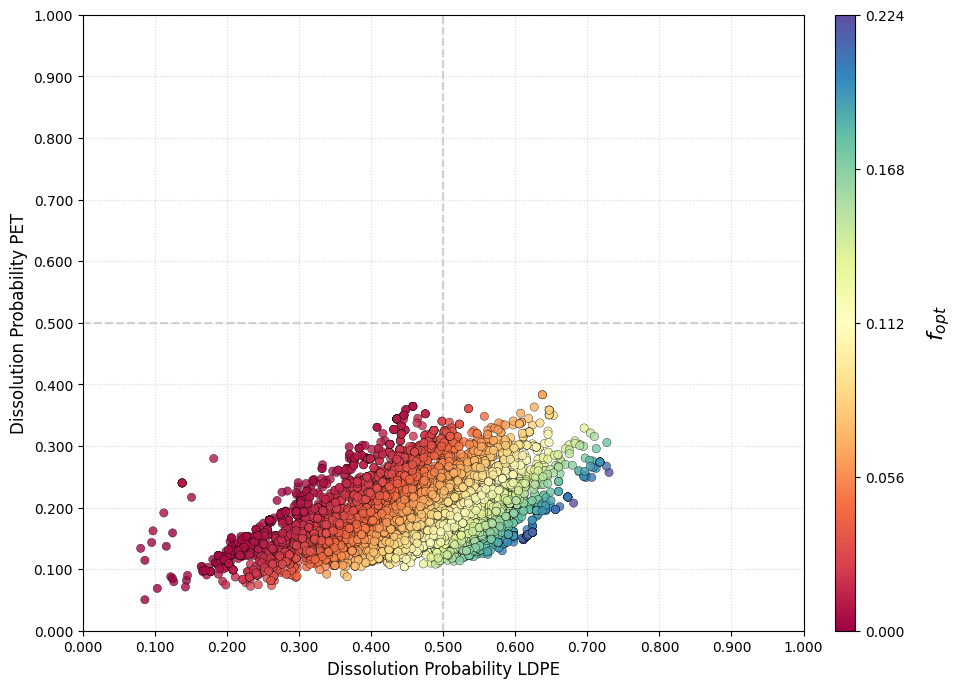

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

norm = mcolors.Normalize(vmin=df['Fitness'].min(), vmax=df['Fitness'].max())
cmap = plt.get_cmap('Spectral')

scatter = sns.scatterplot(
    data=df,
    x='Dissolution_LDPE',
    y='Dissolution_PET',
    hue='Fitness',
    palette='Spectral',
    hue_norm=(df['Fitness'].min(), df['Fitness'].max()),
    alpha=0.8,
    edgecolor='black',
    linewidth=0.3,
    zorder=2,
    ax=ax
)


ax.set_xlabel('Dissolution Probability LDPE', fontsize=12)
ax.set_ylabel('Dissolution Probability PET', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax.axvline(x=0.5, color='darkgray', linestyle='--', alpha=0.5, zorder=0)
ax.axhline(y=0.5, color='darkgray', linestyle='--', alpha=0.5, zorder=0)
ax.grid(True, linestyle=':', alpha=0.5)
ax.get_legend().remove()

sm = cm.ScalarMappable(cmap='Spectral', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax,pad=0.04, fraction=0.03, aspect=30)      

cbar.set_label('$f_{opt}$', fontsize=16, labelpad=15)

tick_values = np.linspace(df['Fitness'].min(), df['Fitness'].max(), 5)
cbar.set_ticks(tick_values)
cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
plt.show()